# Analysis of the Relationship Between Weather Conditions and Traffic offence Frequencies

## Executive summary

Speeding offences in Bonn rise and fall with the seasons — and so does the weather, which makes the two look strongly related. In the raw 2022 data, daily offences correlate most with **temperature** (*r* = +0.38). But almost all of that is the shared yearly cycle: summer brings warmer days *and* more offences (more traffic, daylight and enforcement).

Once the seasonal cycle is removed — comparing days *within the same month* — the headline correlations collapse. Temperature falls to *r* = +0.03 (not significant), and dew point, humidity and wind speed lose their signal too. The only weather variable with a genuine day-to-day association is **precipitation**: offences dip slightly on rainier days (Spearman ρ = −0.19). A weekday pattern (Thursday/Friday highest, Sunday lowest) points to traffic *exposure and enforcement* as the real drivers.

**Takeaway:** in this dataset, weather is a weak, mostly-seasonal correlate of speeding offences in Bonn — not a driver. The *Significance & seasonality* section below shows the full analysis.

## Contents
1. Introduction: A brief overview of the project.
2. Datasets: A brief overview of the datasets.
3. Import Packages: Import the necessary packages.
4. Data Loading: Load the data into a notebook.
5. Data Inspection: Explore the dataset for basic understanding.
6. Data Visualization: Create visualizations to explore the data and gain insights.
7. Results
    * Correlation Analysis: Analyze the correlation between data.
    * Significance & Seasonality: Test which correlations survive removing the yearly cycle.
    * Individual Line Chart: Compare and analyse individual line charts to find patterns.
    * Scatter Plots: Analysis of the scatter plots of the variables with significant correlations against the traffic offence frequencies.
8. Interpretation of Results: Summarize the key findings and insights obtained from the data exploration.
9. Limitations: Limitations of the analysis and data.
10. Future work: Analyze the scope of future work.

# Introduction
Traffic offences are a significant concern for public safety and urban planning. Understanding the factors influencing traffic violations is crucial for developing effective strategies to reduce them. This report investigates the potential relationship between various weather conditions and the frequency of traffic offences. The motivation behind this study is to explore whether specific weather parameters can be indicators or contributors to changes in the number of traffic offences, thereby aiding in better traffic management and safety measures.

### Datasets
The following datasets are used in this project:
1. Speed limit This dataset contains information on fines for speeding in the Bonn City area in 2022. It includes the date, time, place, fines, and offence number.
    * Datasource name: Bußgelder fließender Verkehr 2022
    * Metadata URL: https://mobilithek.info/offers/-5415240082314561823
    * Data URL: https://opendata.bonn.de/sites/default/files/Geschwindigkeitsverstoesse2022.csv
    * Data Type: CSV
2. Weather dataset: This dataset is generated from the POWER project of NASA (Nasa power API).
    * Datasource2: NASA Prediction Of Worldwide Energy Resources
    * Metadata URL: https://power.larc.nasa.gov/data-access-viewer
    * Data URL: https://power.larc.nasa.gov/data-access-viewer
    * Data Type: JSON (NASA POWER API)
    
    This weather dataset is generated from the POWER project using the following options:
    * Date: Jan 01, 2022 to Dec 31, 2022
    * Temporal: Daily
    * Location: Bonn
    * Parameter(s): 
        * T2M             MERRA-2 Temperature at 2 Meters (C) 
        * T2MDEW          MERRA-2 Dew/Frost Point at 2 Meters (C) 
        * QV2M            MERRA-2 Specific Humidity at 2 Meters (g/kg) 
        * PRECTOTCORR     MERRA-2 Precipitation Corrected (mm/day) 
        * PS              MERRA-2 Surface Pressure (kPa) 
        * WS10M           MERRA-2 Wind Speed at 10 Meters (m/s) 
        * WD10M           MERRA-2 Wind Direction at 10 Meters (Degrees) 

# Methods

### Import Packages
Import the necessary packages that will be used in the exploration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import calendar

### Data Loading
Load the SQLite data file into the notebook using pandas. data is already cleaned and merged during the creation of the SQLite database.

In [2]:
df = pd.read_sql_table('weather_traffic_fines', 'sqlite:///data/data.sqlite')

### Data Inspection
Explore the dataset by examining its structure, dimensions, and basic properties to get an initial understanding of the data.

In [3]:
df.head(5)

,DATE,T2M,T2MDEW,QV2M,PRECTOTCORR,PS,WS10M,WD10M,TRAFFIC OFFENCE FREQUENCIES
0,2022-01-01,8.74,8.09,6.88,0.11,97.96,5.13,214.6,199
1,2022-01-02,7.61,6.01,6.04,1.96,97.11,7.83,229.1,162
2,2022-01-03,7.14,6.08,6.07,5.73,96.67,7.70,243.8,297
3,2022-01-04,4.27,3.70,5.22,15.48,95.43,3.80,254.3,255
4,2022-01-05,0.79,0.00,3.97,2.29,96.24,7.89,278.8,401


In [4]:
df.tail(5)

,DATE,T2M,T2MDEW,QV2M,PRECTOTCORR,PS,WS10M,WD10M,TRAFFIC OFFENCE FREQUENCIES
360,2022-12-27,2.57,1.93,4.47,0.21,97.96,6.59,224.4,443
361,2022-12-28,5.58,4.76,5.55,2.14,96.82,9.40,211.3,431
362,2022-12-29,6.99,5.48,5.86,1.76,96.29,9.45,228.3,444
363,2022-12-30,6.34,5.72,6.03,3.79,96.43,8.83,203.3,391
364,2022-12-31,11.63,9.82,7.86,1.11,96.67,11.03,218.9,415


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   DATE                         365 non-null    datetime64[us]
 1   T2M                          365 non-null    float64       
 2   T2MDEW                       365 non-null    float64       
 3   QV2M                         365 non-null    float64       
 4   PRECTOTCORR                  365 non-null    float64       
 5   PS                           365 non-null    float64       
 6   WS10M                        365 non-null    float64       
 7   WD10M                        365 non-null    float64       
 8   TRAFFIC OFFENCE FREQUENCIES  365 non-null    int64         
dtypes: datetime64[us](1), float64(7), int64(1)
memory usage: 25.8 KB


### Data validation

Before analysing, confirm the merged dataset is complete and free of NASA POWER's `-999` missing-value sentinel.

In [6]:
weather_cols = ['T2M', 'T2MDEW', 'QV2M', 'PRECTOTCORR', 'PS', 'WS10M', 'WD10M']
checks = {
    'missing values (NaN)': int(df[weather_cols].isna().sum().sum()),
    'NASA -999 sentinels': int((df[weather_cols] <= -998).sum().sum()),
    'duplicate dates': int(df['DATE'].duplicated().sum()),
}
print(f"Days: {len(df)}  ({df['DATE'].min().date()} to {df['DATE'].max().date()})")
for name, count in checks.items():
    print(f"  {name}: {count}")

Days: 365  (2022-01-01 to 2022-12-31)
  missing values (NaN): 0
  NASA -999 sentinels: 0
  duplicate dates: 0


### Data Visualization

Create visualizations to explore the data and gain insights by using plotting libraries.

A Boxplot is created to get the visual summary of the variability of values in a dataset to show the median, upper and lower quartiles, minimum and maximum values, and any outliers in the dataset.

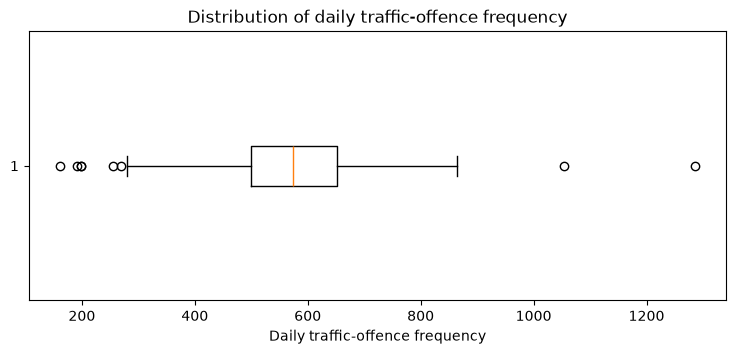

count     365.000000
mean      573.616438
std       129.827932
min       162.000000
25%       500.000000
50%       574.000000
75%       651.000000
max      1285.000000
Name: TRAFFIC OFFENCE FREQUENCIES, dtype: float64

In [7]:
plt.figure(figsize=(9, 3.5))
plt.boxplot(df['TRAFFIC OFFENCE FREQUENCIES'], orientation='horizontal')
plt.xlabel('Daily traffic-offence frequency')
plt.title('Distribution of daily traffic-offence frequency')
plt.show()

# Summary statistics
df['TRAFFIC OFFENCE FREQUENCIES'].describe()

The trend of traffic fine frequencies each day over the year 2022 is observed from the following line chart.

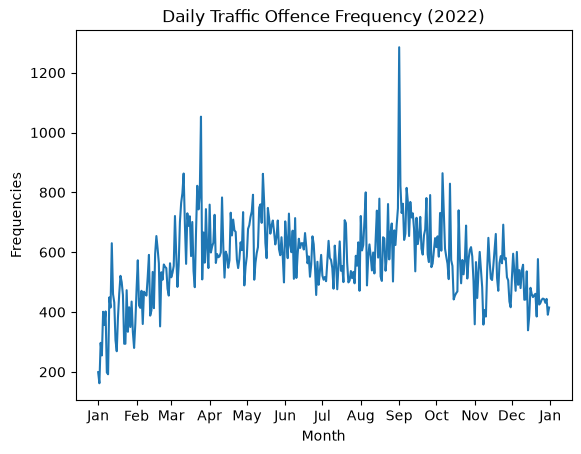

In [8]:
# Frequencies of traffic fines each day over the year.
plt.plot(df['DATE'], df['TRAFFIC OFFENCE FREQUENCIES'])
plt.xlabel('Month')
plt.ylabel('Frequencies')
plt.title('Daily Traffic Offence Frequency (2022)')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.show()

The count of traffic violations exhibits a rising pattern from July to September.

More insights are observed from the following bar chart and violin chart.  

[11317 13918 20503 18644 20639 17987 17187 19531 20913 18428 15700 14603]


Text(0.5, 1.0, 'Monthly Traffic Offence Totals')

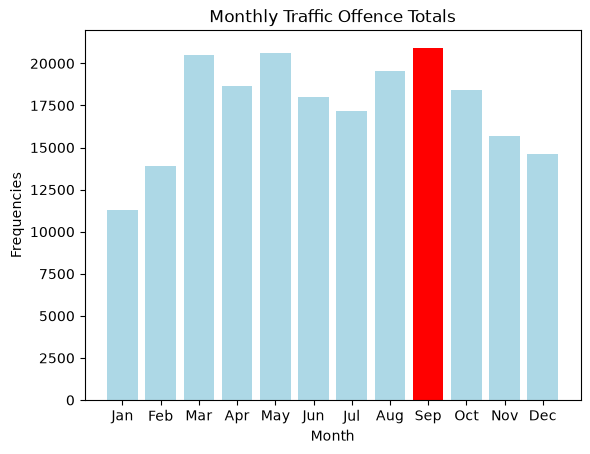

In [9]:
# Group the data by month and sum the frequencies

df_monthly = df.groupby(df['DATE'].dt.month)['TRAFFIC OFFENCE FREQUENCIES'].sum()
df_month_names = df.groupby(df['DATE'].dt.month)['DATE']
month_names = [calendar.month_name[i][:3] for i in df_monthly.index]
print(df_monthly.values)
color = ['lightblue' if (x < max(df_monthly.values)) else 'red' for x in df_monthly.values ]
plt.bar(month_names, df_monthly.values, color=color)
plt.xlabel('Month')
plt.ylabel('Frequencies')
plt.title('Monthly Traffic Offence Totals')

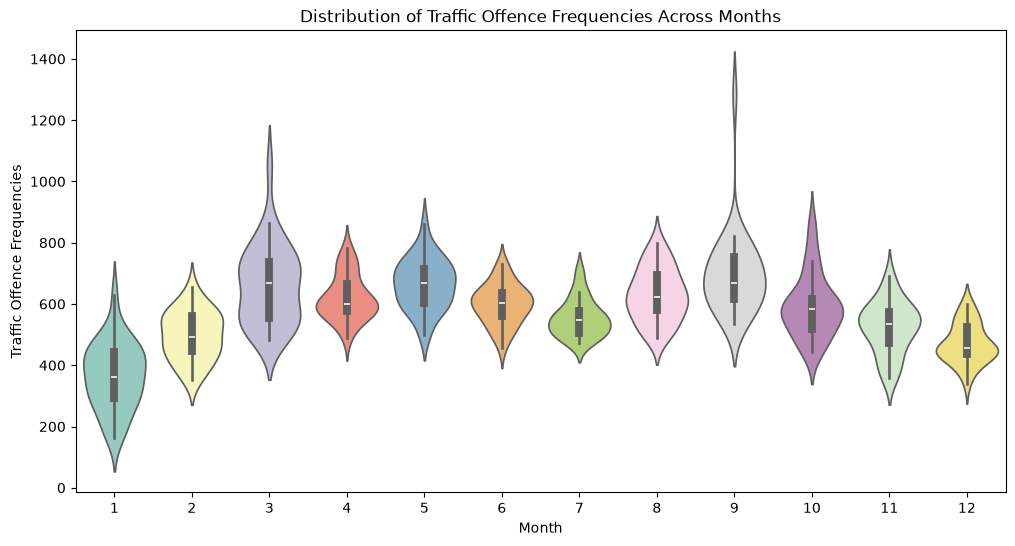

In [10]:
# Violin Plot for comparing the distribution of Traffic Offence Frequencies across different months

plt.figure(figsize=(12, 6))
sns.violinplot(x=df['DATE'].dt.month, y='TRAFFIC OFFENCE FREQUENCIES', data=df, hue=df['DATE'].dt.month, palette='Set3', legend=False)
plt.title('Distribution of Traffic Offence Frequencies Across Months')
plt.xlabel('Month')
plt.ylabel('Traffic Offence Frequencies')
plt.show()

In the month of September, the highest number of instances was observed.

The bar charts presented below depict the frequency of events on a quarterly basis.

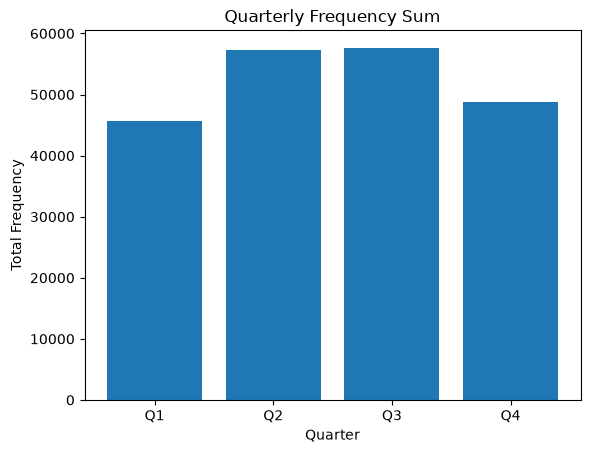

In [11]:
# Group the data by quarter and sum the frequencies
df_quarterly = df.groupby(df['DATE'].dt.quarter)['TRAFFIC OFFENCE FREQUENCIES'].sum()

# Get the quarter labels
quarter_labels = [f'Q{i+1}' for i in range(len(df_quarterly))]

# Plot the data as a bar chart
plt.bar(quarter_labels, df_quarterly)
plt.xlabel('Quarter')
plt.ylabel('Total Frequency')
plt.title('Quarterly Frequency Sum')

plt.show()

As anticipated based on the previous data, the third quarter has the highest total, narrowly ahead of the second quarter.

The following chart illustrates the temperature data throughout the year. 

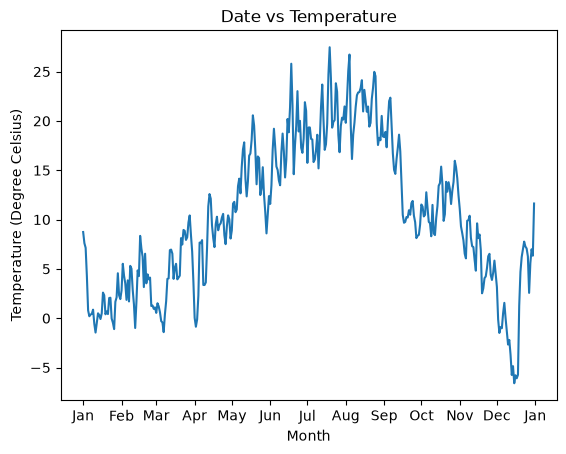

In [12]:
plt.plot(df['DATE'], df['T2M'])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xlabel('Month')
plt.ylabel('Temperature (Degree Celsius)')
plt.title('Date vs Temperature')
plt.show()

The following chart illustrates the monthly average temperature data throughout the year. 

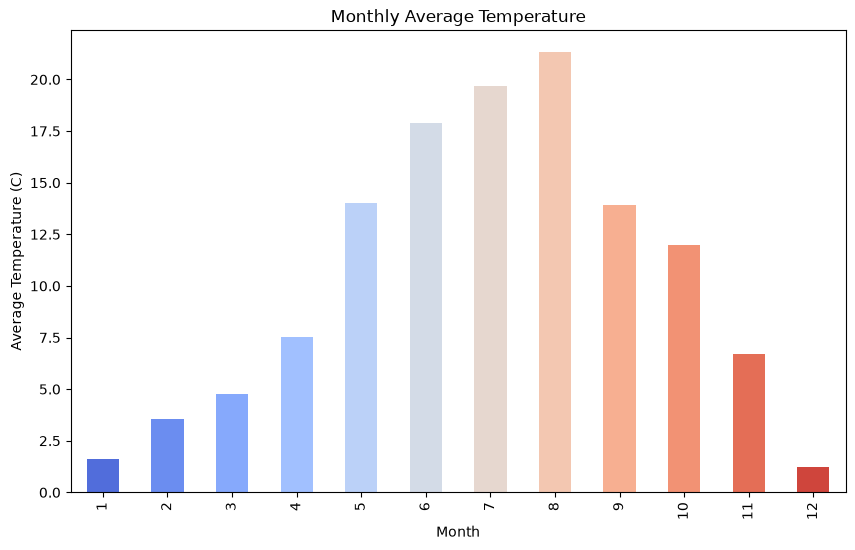

In [13]:
# Monthly Average Temperature
monthly_avg_temp = df.groupby(df['DATE'].dt.month)['T2M'].mean()
plt.figure(figsize=(10, 6))
monthly_avg_temp.plot(kind='bar', color=sns.color_palette("coolwarm", 12))
plt.title('Monthly Average Temperature')
plt.xlabel('Month')
plt.ylabel('Average Temperature (C)')
plt.show()

Overall, the third quarter experiences the highest temperature. Specially July and August stand out from other months.

The below chart displays the Dew/Frost point information for the entire year.


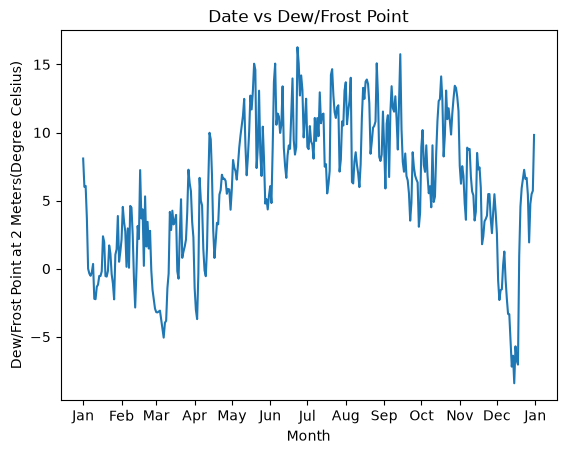

In [14]:
plt.plot(df['DATE'], df['T2MDEW'])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xlabel('Month')
plt.ylabel('Dew/Frost Point at 2 Meters(Degree Celsius)')
plt.title('Date vs Dew/Frost Point')
plt.show()

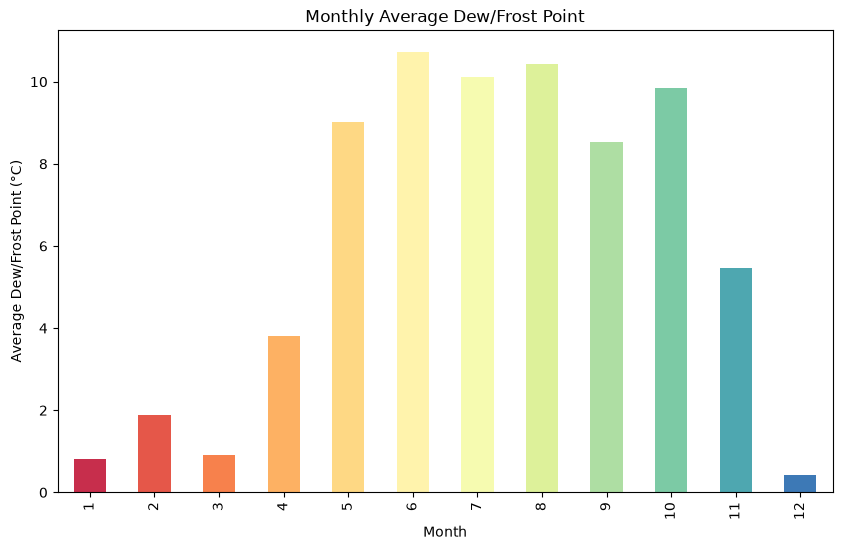

In [15]:
# Monthly Average Dew/Frost Point
monthly_avg_dew = df.groupby(df['DATE'].dt.month)['T2MDEW'].mean()
plt.figure(figsize=(10, 6))
monthly_avg_dew.plot(kind='bar', color=sns.color_palette("Spectral", 12))
plt.title('Monthly Average Dew/Frost Point')
plt.xlabel('Month')
plt.ylabel('Average Dew/Frost Point (°C)')
plt.show()

The Dew/Frost point fluctuated entire year but from May to October average is higher.

The below chart displays the Specific Humidity information for the entire year.

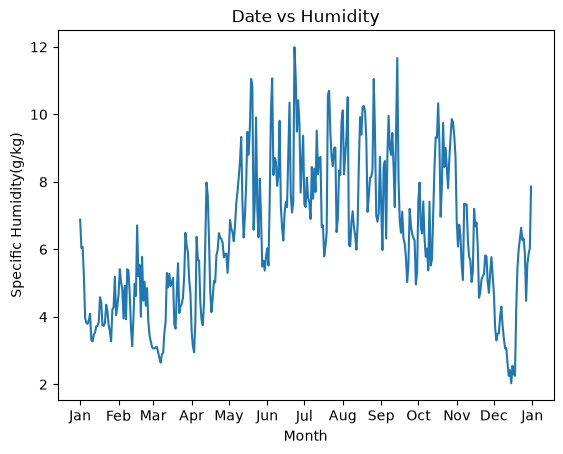

In [16]:
plt.plot(df['DATE'], df['QV2M'])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xlabel('Month')
plt.ylabel('Specific Humidity(g/kg)')
plt.title('Date vs Humidity')
plt.show()

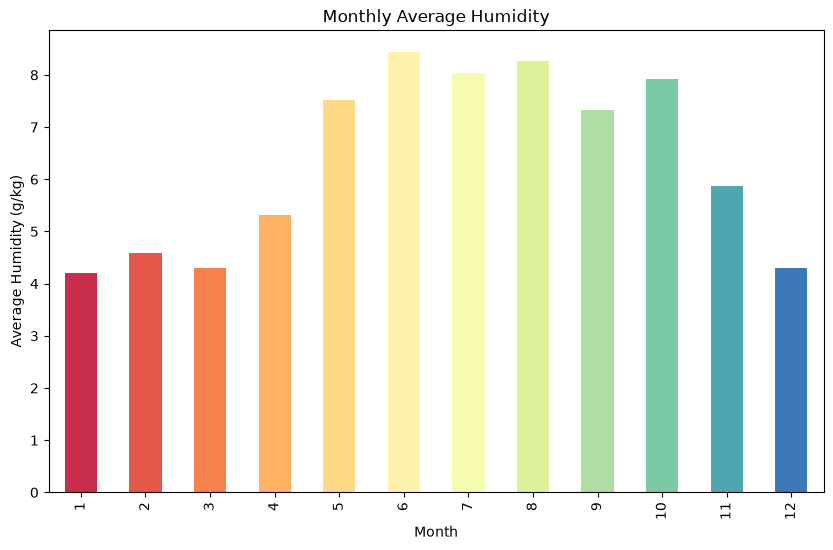

In [17]:
# Monthly Average Humidity
monthly_avg_humidity = df.groupby(df['DATE'].dt.month)['QV2M'].mean()
plt.figure(figsize=(10, 6))
monthly_avg_humidity.plot(kind='bar', color=sns.color_palette("Spectral", 12))
plt.title('Monthly Average Humidity')
plt.xlabel('Month')
plt.ylabel('Average Humidity (g/kg)')
plt.show()

The Specific Humidity at 2 Meters (g/kg) was increased second and third quarter.

The below chart displays the precipitation information for the entire year.

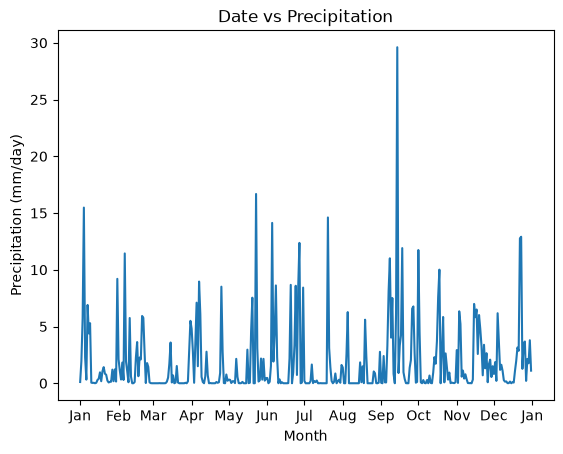

In [18]:
plt.plot(df['DATE'], df['PRECTOTCORR'])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xlabel('Month')
plt.ylabel('Precipitation (mm/day)')
plt.title('Date vs Precipitation')
plt.show()

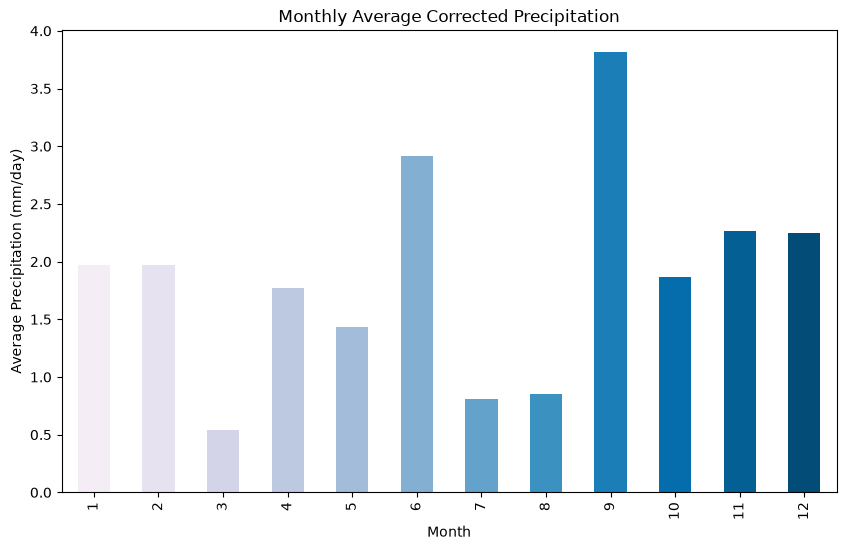

In [19]:
# Monthly Average Corrected Precipitation
monthly_avg_precip = df.groupby(df['DATE'].dt.month)['PRECTOTCORR'].mean()
plt.figure(figsize=(10, 6))
monthly_avg_precip.plot(kind='bar', color=sns.color_palette("PuBu", 12))
plt.title('Monthly Average Corrected Precipitation')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (mm/day)')
plt.show()

Regular precipitation was recorded at the beginning and end of the year. However, there was intermittent rain in the September.

The below chart provides insights into the Surface Pressure throughout the year.

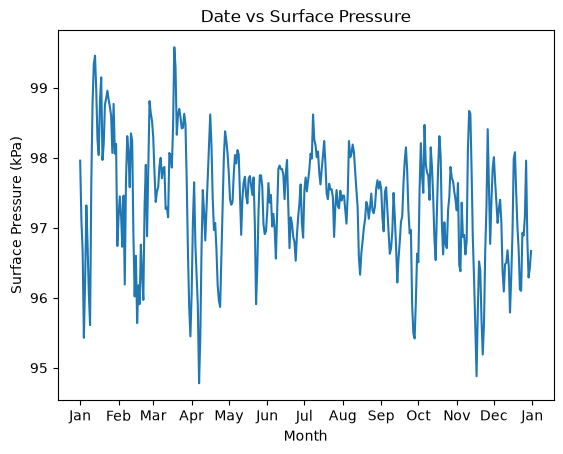

In [20]:
plt.plot(df['DATE'], df['PS'])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xlabel('Month')
plt.ylabel('Surface Pressure (kPa)')
plt.title('Date vs Surface Pressure')
plt.show()

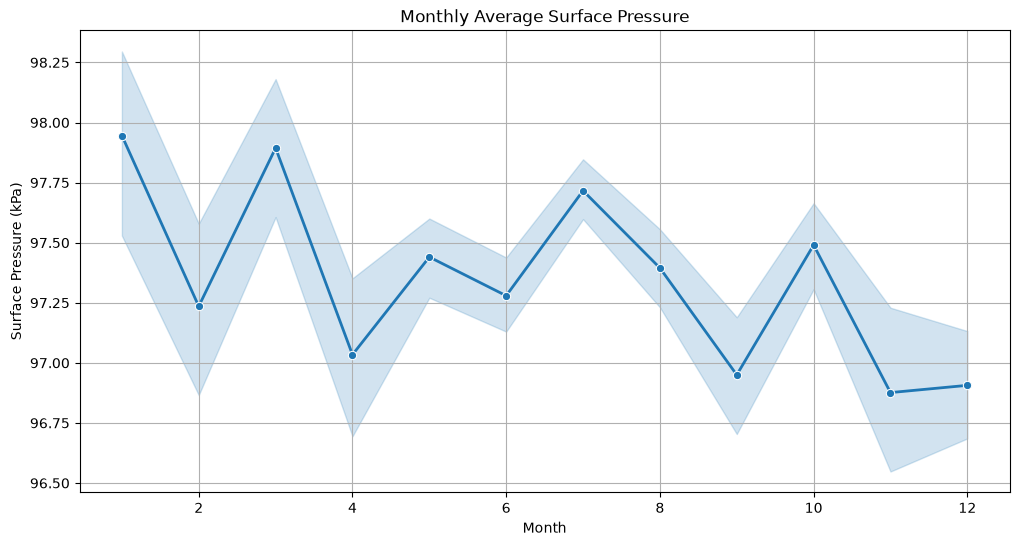

In [21]:
# Monthly average Surface pressure 

plt.figure(figsize=(12, 6))
sns.lineplot(x=df['DATE'].dt.month, y='PS', data=df, marker='o', lw=2, legend=False)
plt.title('Monthly Average Surface Pressure')
plt.xlabel('Month')
plt.ylabel('Surface Pressure (kPa)')
plt.grid(True)
plt.show()

Surface Pressure is fluctuated throughout the year but the range is very small.

The below charts provides insights into the wind speed throughout the year.

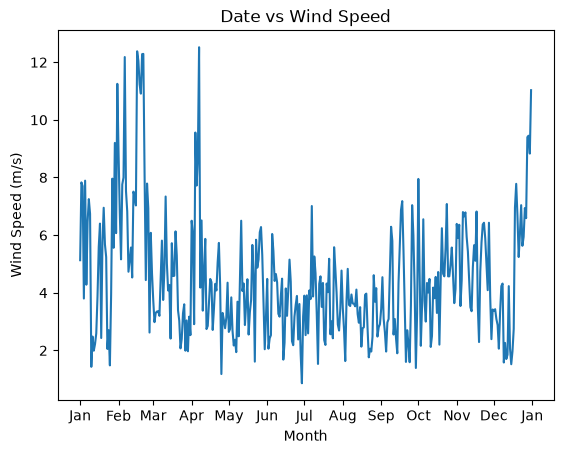

In [22]:
plt.plot(df['DATE'], df['WS10M'])
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xlabel('Month')
plt.ylabel('Wind Speed (m/s)')
plt.title('Date vs Wind Speed')
plt.show()

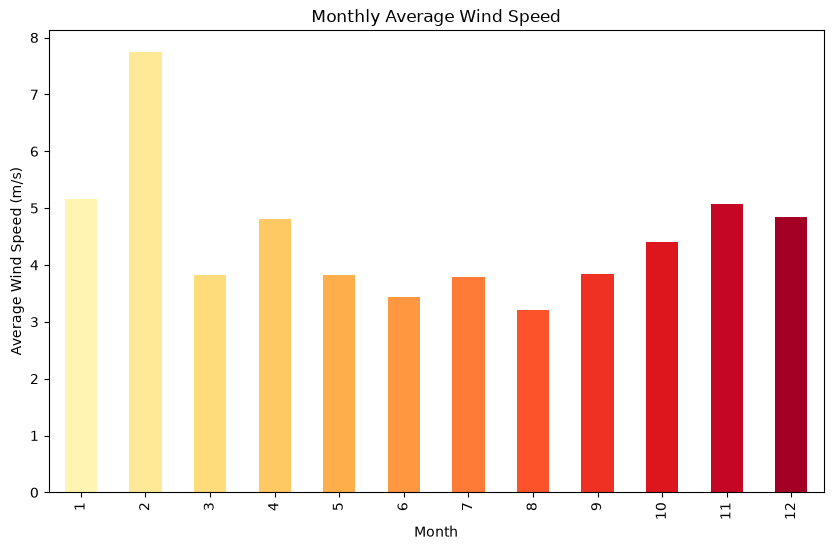

In [23]:
# Monthly Average Wind Speed

monthly_avg_wind_speed = df.groupby(df['DATE'].dt.month)['WS10M'].mean()
plt.figure(figsize=(10, 6))
monthly_avg_wind_speed.plot(kind='bar', color=sns.color_palette("YlOrRd", 12))
plt.title('Monthly Average Wind Speed')
plt.xlabel('Month')
plt.ylabel('Average Wind Speed (m/s)')
plt.show()

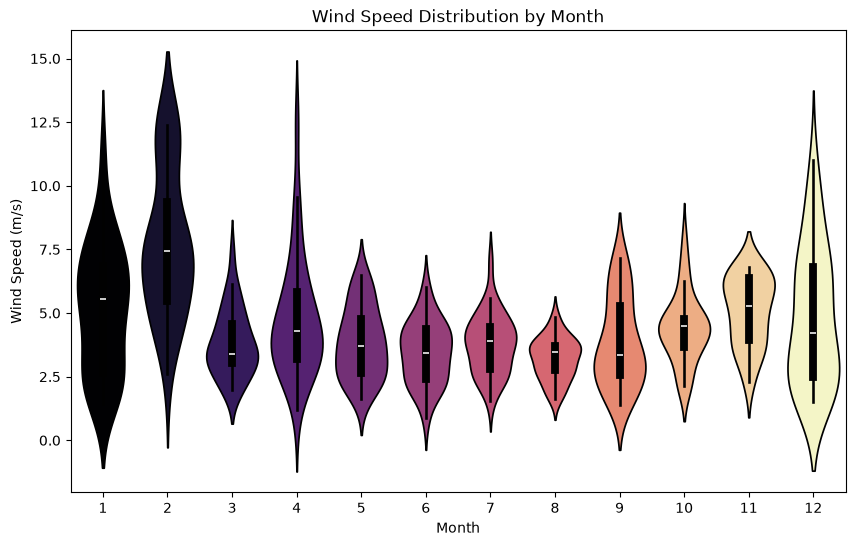

In [24]:
# Violin Plot for Wind Speed Distribution by Month
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['DATE'].dt.month, y='WS10M', data=df, hue=df['DATE'].dt.month, palette='magma', legend=False)
plt.title('Wind Speed Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Wind Speed (m/s)')
plt.show()

The wind speed observed during the first and last quarter was greater compared to the rest of the year.

The below chart provides insights into the wind direction throughout the year.

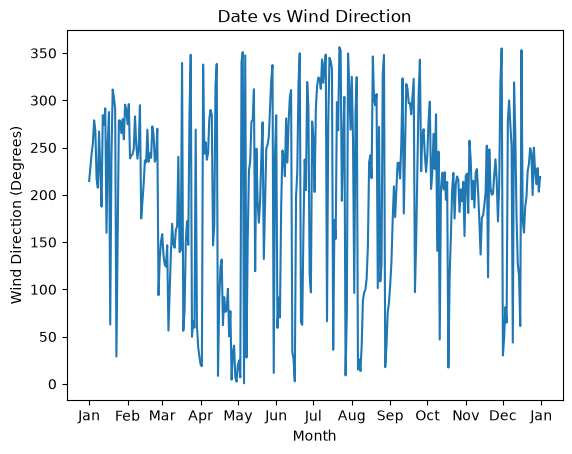

In [25]:
plt.plot(df['DATE'], df['WD10M'])
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xlabel('Month')
plt.ylabel('Wind Direction (Degrees)')
plt.title('Date vs Wind Direction')
plt.show()

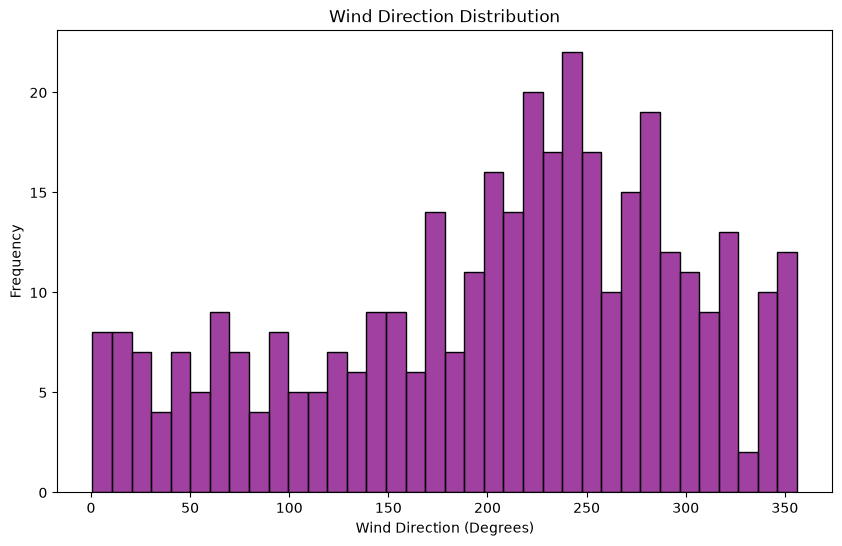

In [26]:
# Wind Direction Distribution

plt.figure(figsize=(10, 6))
sns.histplot(df['WD10M'], bins=36, color='purple')
plt.title('Wind Direction Distribution')
plt.xlabel('Wind Direction (Degrees)')
plt.ylabel('Frequency')
plt.show()

Wind Direction is fluctuated throughout the year but mostly directed to 150 to 300 degree.


# Results

### Correlation Analysis
To get the correlation between the frequencies of traffic fines and weather data, the following charts are created by combining the above data.

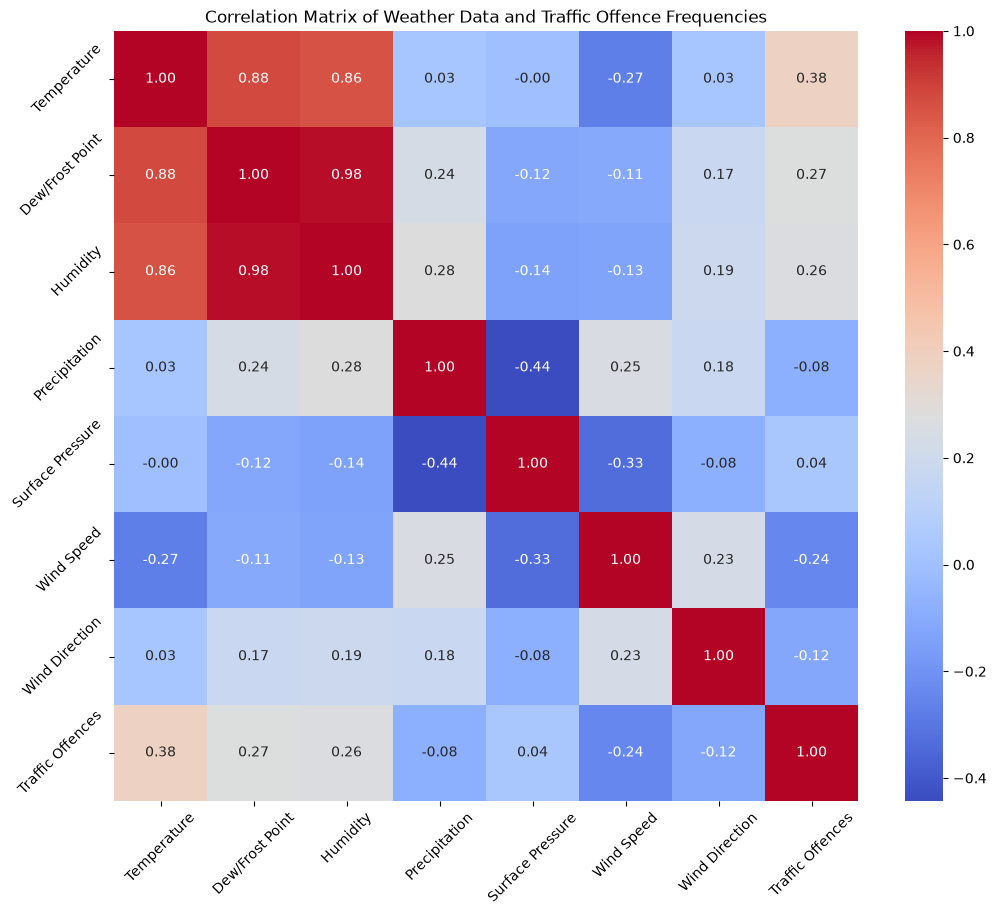

TRAFFIC OFFENCE FREQUENCIES    1.000000
T2M                            0.377579
T2MDEW                         0.274621
QV2M                           0.263530
PS                             0.035964
PRECTOTCORR                   -0.077450
WD10M                         -0.116933
WS10M                         -0.243585
Name: TRAFFIC OFFENCE FREQUENCIES, dtype: float64

In [27]:
# Calculating correlation matrix
correlation_matrix = df.corr(numeric_only = True)

# Dictionary for mapping column names to their descriptions
column_descriptions = {
    'T2M': 'Temperature',
    'T2MDEW': 'Dew/Frost Point',
    'QV2M': 'Humidity',
    'PRECTOTCORR': 'Precipitation',
    'PS': 'Surface Pressure',
    'WS10M': 'Wind Speed',
    'WD10M': 'Wind Direction',
    'TRAFFIC OFFENCE FREQUENCIES': 'Traffic Offences'
}

# Updating the column names in the correlation matrix for plotting
correlation_matrix_renamed = correlation_matrix.rename(columns=column_descriptions, index=column_descriptions)

# Plotting the correlation matrix with updated names
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_renamed, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Weather Data and Traffic Offence Frequencies")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

# Displaying the correlation values specifically for 'TRAFFIC OFFENCE FREQUENCIES'
correlation_with_traffic_offences = correlation_matrix['TRAFFIC OFFENCE FREQUENCIES'].sort_values(ascending=False)
correlation_with_traffic_offences

The correlation analysis reveals the following relationships between traffic offence frequencies and the weather parameters:

1. T2M (Temperature): A moderate positive correlation (0.38). This suggests a relationship where higher temperatures are associated with more traffic offences.

2. T2MDEW (Dew/Frost Point) and QV2M (Specific Humidity): Both show a positive correlation (0.27 and 0.26, respectively), indicating a slight tendency for traffic offences to increase with higher humidity and dew point levels.

3. PS (Surface Pressure): A very weak positive correlation (0.04), suggesting a negligible relationship between surface pressure and traffic offences.

4. PRECTOTCORR (Precipitation Corrected): A weak negative correlation (-0.08), indicating a slight tendency for traffic offences to decrease with higher precipitation.

5. WD10M (Wind Direction) and WS10M (Wind Speed): Negative correlations (-0.12 and -0.24, respectively), suggesting a tendency for traffic offences to decrease with changes in wind direction and increases in wind speed.

These correlations provide insights into the relationships between weather conditions and traffic offences, although it's important to remember that correlation does not imply causation. Further investigation would be necessary to understand the underlying causes of these correlations. 

### Significance & seasonality

The correlations above use raw daily values, so they capture two things at once: genuine day-to-day weather effects **and** the shared seasonal cycle (both weather and offences follow the calendar). Two checks separate them:

1. **Significance** — with 365 days even a weak correlation can be "significant", so we report *p*-values alongside *r*, plus Spearman's ρ (robust to the skew in rainfall and offence counts).
2. **Deseasonalizing** — subtracting each variable's monthly mean removes the yearly cycle, leaving day-to-day *anomalies*. A relationship that survives on anomalies is a real within-month effect rather than a seasonal coincidence.

In [28]:
# Significance and seasonality of each correlation
params = ['T2M', 'T2MDEW', 'QV2M', 'PRECTOTCORR', 'PS', 'WS10M', 'WD10M']
target = 'TRAFFIC OFFENCE FREQUENCIES'

# Day-to-day anomalies: subtract each column's monthly mean to remove the yearly cycle
month = df['DATE'].dt.month
anomalies = df[params + [target]] - df[params + [target]].groupby(month).transform('mean')

def fmt_p(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

rows = []
for c in params:
    r, p_r     = stats.pearsonr(df[c], df[target])
    rho, p_rho = stats.spearmanr(df[c], df[target])
    dr, p_dr   = stats.pearsonr(anomalies[c], anomalies[target])
    rows.append([column_descriptions[c], round(r, 3), fmt_p(p_r),
                 round(rho, 3), round(dr, 3), fmt_p(p_dr)])

stats_table = pd.DataFrame(rows, columns=['Weather', 'Pearson r', 'p',
                                          'Spearman rho', 'Deseasonalized r', 'p (deseason)'])
stats_table = (stats_table
               .reindex(stats_table['Pearson r'].abs().sort_values(ascending=False).index)
               .reset_index(drop=True))
stats_table

,Weather,Pearson r,p,Spearman rho,Deseasonalized r,p (deseason)
0,Temperature,0.378,<0.001,0.401,0.034,0.515
1,Dew/Frost Point,0.275,<0.001,0.293,-0.072,0.167
2,Humidity,0.264,<0.001,0.291,-0.078,0.136
3,Wind Speed,-0.244,<0.001,-0.206,-0.048,0.356
4,Wind Direction,-0.117,0.025,-0.089,-0.001,0.982
5,Precipitation,-0.077,0.140,-0.192,-0.106,0.042
6,Surface Pressure,0.036,0.493,0.009,0.131,0.012


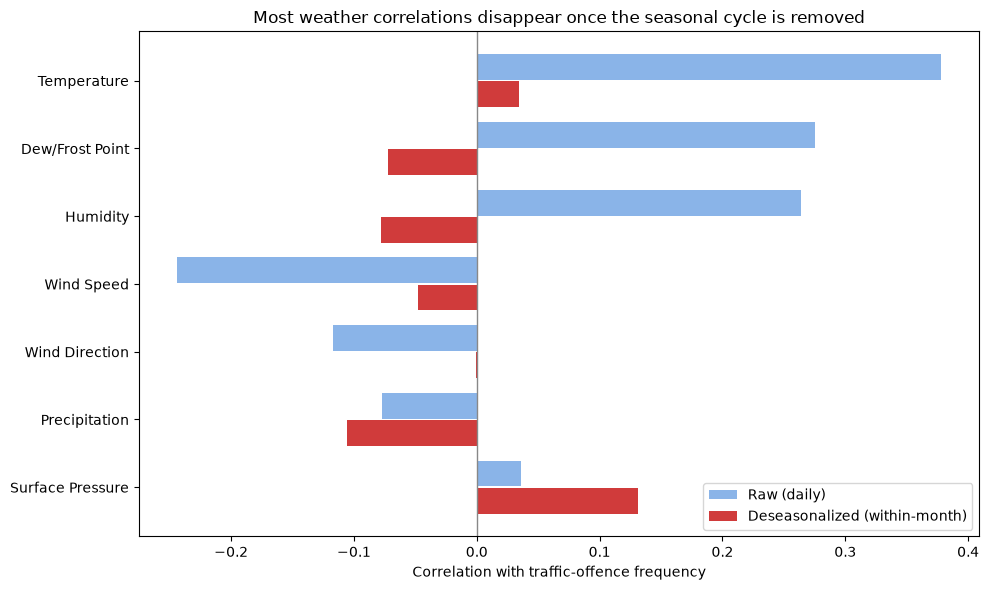

In [29]:
# Raw vs deseasonalized correlations
comp = stats_table.set_index('Weather')[['Pearson r', 'Deseasonalized r']]
yy = np.arange(len(comp))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(yy - 0.2, comp['Pearson r'], height=0.38, color='#8ab4e8', label='Raw (daily)')
ax.barh(yy + 0.2, comp['Deseasonalized r'], height=0.38, color='#d03b3b', label='Deseasonalized (within-month)')
ax.axvline(0, color='#888888', lw=1)
ax.set_yticks(yy); ax.set_yticklabels(comp.index); ax.invert_yaxis()
ax.set_xlabel('Correlation with traffic-offence frequency')
ax.set_title('Most weather correlations disappear once the seasonal cycle is removed')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

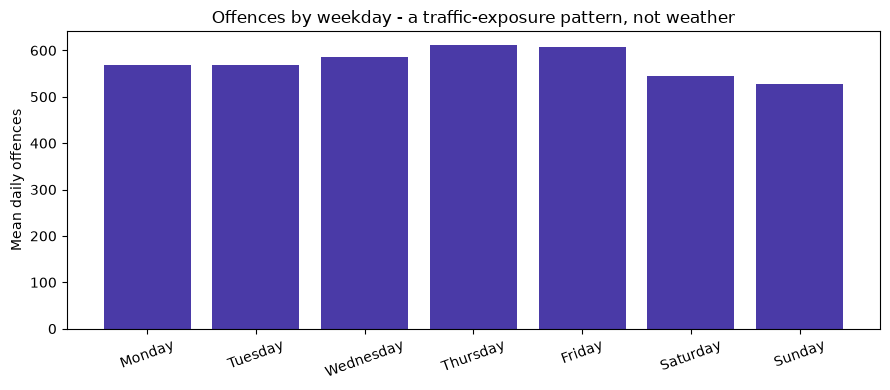

In [30]:
# Offence frequency by weekday
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday = df.groupby(df['DATE'].dt.day_name())[target].mean().reindex(order)

plt.figure(figsize=(9, 4))
plt.bar(weekday.index, weekday.values, color='#4a3aa7')
plt.ylabel('Mean daily offences')
plt.title('Offences by weekday - a traffic-exposure pattern, not weather')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The table and charts above tell a consistent story: **almost every correlation that looked meaningful in the raw data is driven by the seasonal cycle.**

- **Temperature** collapses from *r* = +0.38 (*p* < 0.001) to *r* = +0.03 (*p* = 0.51) after deseasonalizing — there is no within-month link between temperature and speeding.
- **Dew point, humidity and wind speed** behave identically: strong-looking raw correlations, no surviving day-to-day signal.
- **Precipitation** is the exception — weak in the raw Pearson value (−0.08) but significant once deseasonalized (−0.11, *p* = 0.04) and clearest under Spearman (ρ = −0.19). Offences dip modestly on rainier days.
- **Surface pressure** shows a small positive anomaly correlation (+0.13), most likely an indirect marker of dry, settled weather.

Two caveats keep even these modest effects in perspective. Daily weather is highly autocorrelated, so the effective sample is far smaller than 365 days and the *p*-values overstate confidence. And the offence *count* mixes driver behaviour with enforcement and traffic volume — the weekday chart above (busiest Thursday–Friday, quietest Sunday) is a commuting-exposure signature, not a weather effect.

### Individual Line Chart
To understand the relation between traffic offence and different weather papameters visually the line charts are created. The data are normalized and grouped by month to make the charts easy to understand.

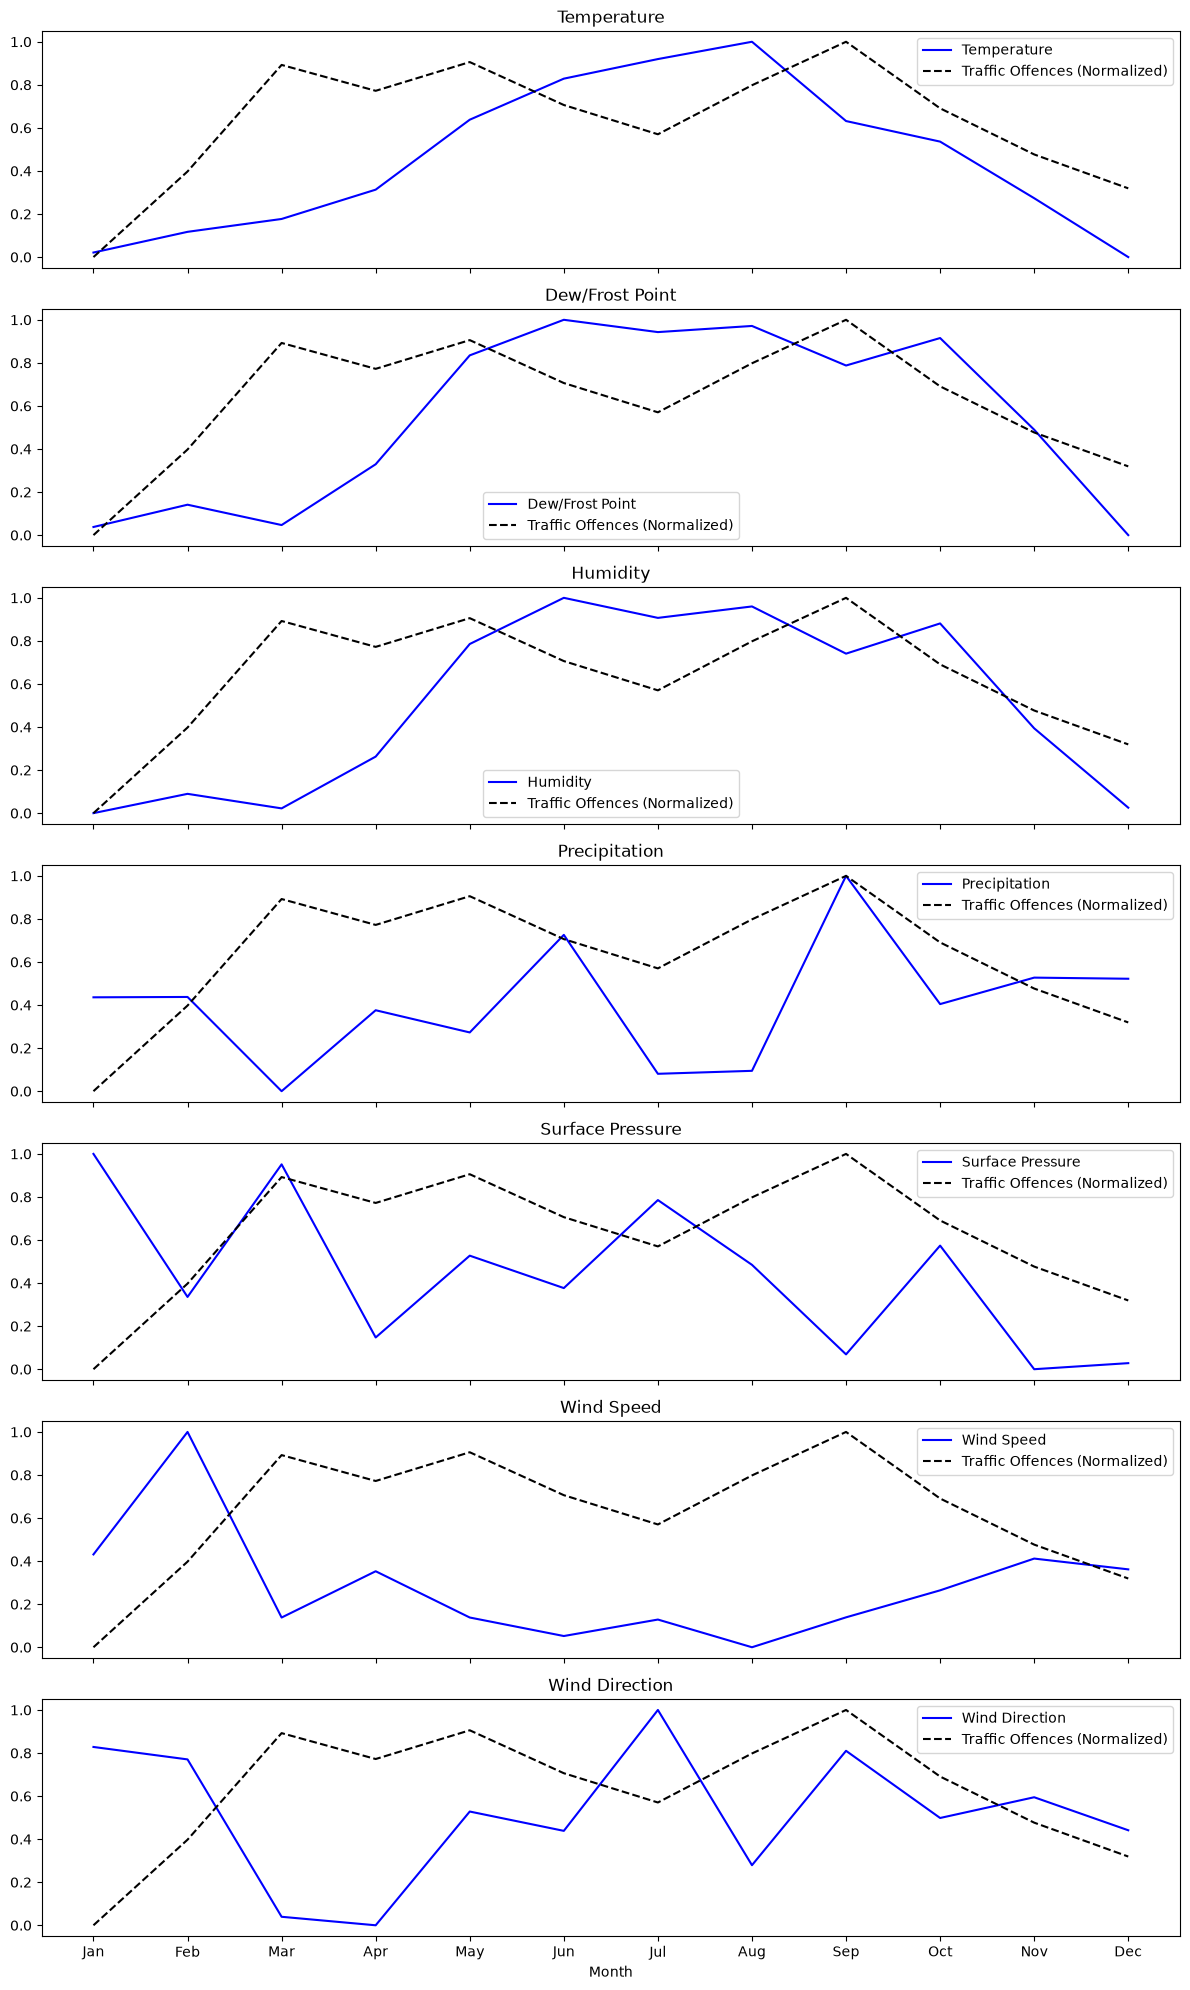

In [31]:
# Calculating monthly means for each column
monthly_means = df.groupby(df['DATE'].dt.month).mean(numeric_only = True)


# Min-max normalize each column to [0, 1]
normalized_data = (monthly_means - monthly_means.min()) / (monthly_means.max() - monthly_means.min())


# Updating the column names in the normalized monthly mean data for plotting
normalized_data_renamed = normalized_data.rename(columns=column_descriptions)

# Creating individual plots for each weather parameter compared to traffic offence frequencies with updated names
fig, axes = plt.subplots(7, 1, figsize=(12, 20), sharex=True)

# Updated list of weather parameters excluding the traffic offence frequencies
weather_parameters_renamed = [col for col in normalized_data_renamed.columns if col != 'Traffic Offences']
# Plotting each weather parameter against traffic offences in a separate subplot
for i, param in enumerate(weather_parameters_renamed):
    axes[i].plot(normalized_data_renamed.index, normalized_data_renamed[param], label=param, color='blue')
    axes[i].plot(normalized_data_renamed.index, normalized_data_renamed['Traffic Offences'], label='Traffic Offences (Normalized)', color='black', linestyle='--')
    axes[i].set_title(param)
    axes[i].legend()

plt.xlabel('Month')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()


This line charts is not explaning any new information. the relation between traffic offences and weather still unclear in the charts.

### Scatter Plots
To further illustrate these relationships, I'll create scatter plots for the variables with significant correlations (T2M, T2MDEW, QV2M, PRECTOTCORR, WS10M and WD10M) against the traffic offence frequencies. 

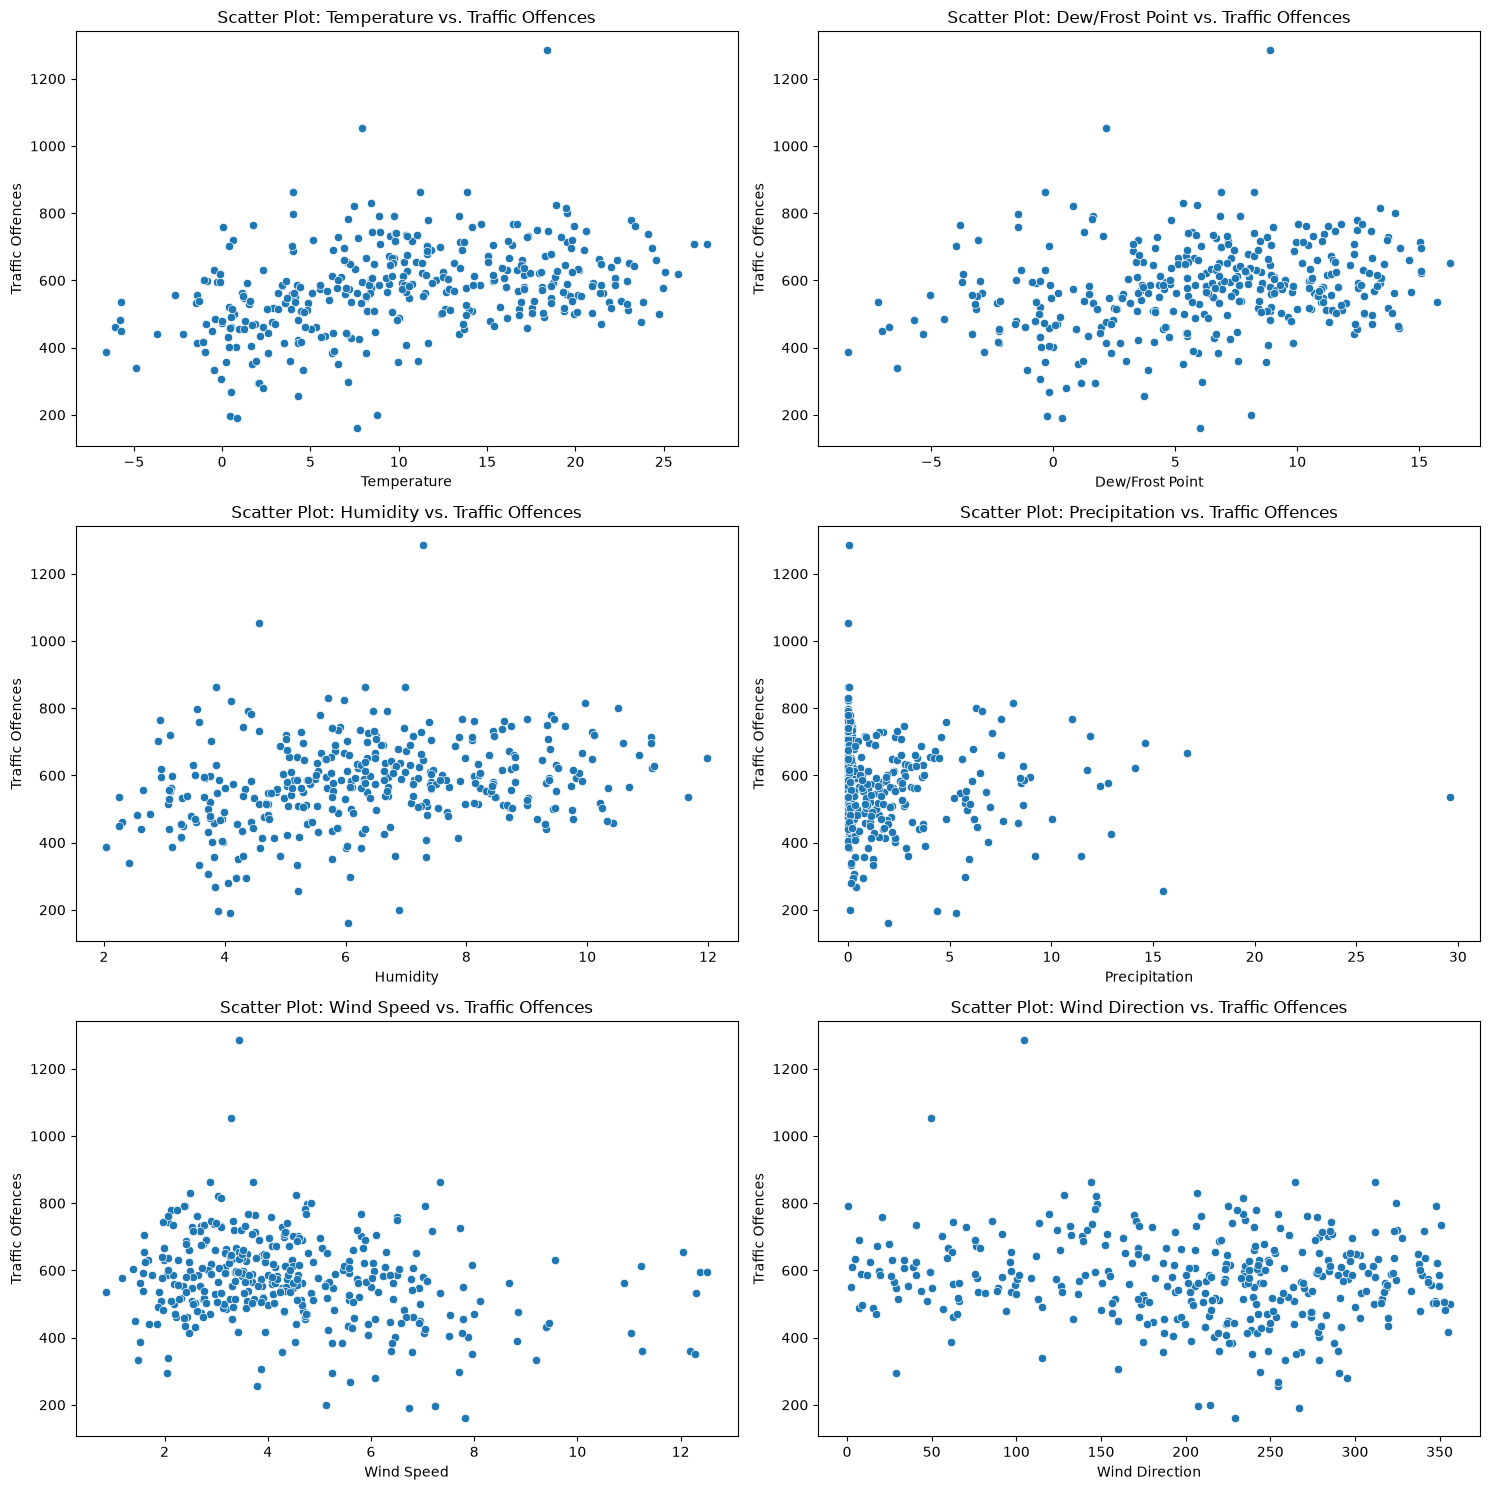

In [32]:
# Scatter plots for variables with significant correlations
significant_variables = ['T2M', 'T2MDEW', 'QV2M', 'PRECTOTCORR', 'WS10M', 'WD10M']

# Setting up the plot
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

# Creating scatter plots
for i, var in enumerate(significant_variables):
    sns.scatterplot(data=df, x=var, y='TRAFFIC OFFENCE FREQUENCIES', ax=axes[i])
    axes[i].set_title(f'Scatter Plot: {column_descriptions[var]} vs. Traffic Offences')
    axes[i].set_xlabel(column_descriptions[var])
    axes[i].set_ylabel('Traffic Offences')

plt.tight_layout()
plt.show()


The scatter plots illustrate the relationships between traffic offence frequencies and various weather parameters:
1. Temperature at 2 Meters (T2M): This shows a pattern where higher temperatures might be associated with more traffic offences.

2.  Dew/Frost Point at 2 Meters (T2MDEW) and Specific Humidity at 2 Meters (QV2M): Indicate a possible trend where higher humidity and dew point levels correspond with increased traffic offences.

3. Corrected Precipitation (PRECTOTCORR): Displays a distribution that suggests a weak inverse relationship, with more precipitation possibly leading to fewer traffic offences.

4. Wind Direction at 10 Meters (WD10M) and Wind Speed at 10 Meters (WS10M): Show trends where certain wind directions and higher wind speeds might be associated with fewer traffic offences.



These visualizations reinforce the correlation findings, but it's important to interpret them cautiously. Correlation does not necessarily mean causation, and other external factors not captured in this data might also play a role in traffic offence frequencies. Additionally, the data set used for this analysis is relatively small, which can affect the reliability of these findings. For a more comprehensive analysis, a larger dataset covering a wider time frame and additional variables could be beneficial.

# Discussion and Conclusions

### Interpretation of results

Taken at face value, the raw correlations suggest that warmer, more humid, less windy days see more speeding offences. The significance-and-seasonality analysis shows this reading is largely an artifact of the **calendar**: weather and offences both follow a strong yearly cycle, and correlating them on raw daily values mostly measures that shared seasonality rather than any direct effect.

- **Temperature, dew point, humidity and wind speed** have sizeable raw correlations but essentially none once the seasonal cycle is removed (temperature: +0.38 → +0.03, *p* = 0.51). Their apparent link to speeding is a seasonal coincidence — summer brings warm weather *and* more driving, daylight and enforcement.
- **Precipitation** is the only weather variable with a genuine within-month signal: offences dip modestly on rainier days (deseasonalized *r* = −0.11, *p* = 0.04; Spearman ρ = −0.19), consistent with more cautious driving or lower traffic in the rain.
- **Surface pressure** shows a weak positive anomaly correlation, most likely an indirect marker of dry, settled conditions rather than a driver in itself.

The strongest pattern in the data is not meteorological at all: offences vary by **weekday** (highest Thursday–Friday, lowest Sunday), a signature of commuting exposure and enforcement scheduling.

### Limitations

- **Seasonal confounding** dominates the raw correlations; only the deseasonalized (within-month) results should be read as day-to-day effects.
- **Offence counts conflate behaviour with enforcement** — a day with more recorded offences may simply reflect more patrols, active speed cameras or higher traffic volume, none of which are in the data.
- **Autocorrelation:** consecutive days share weather and offence levels, so the effective sample is far smaller than 365 and the *p*-values overstate confidence.
- **Single year, single city, linear measures:** one year of Bonn data cannot generalize, and Pearson/Spearman capture only monotonic association. Wind *direction* in particular is circular and not well described by a linear correlation.

### Future work

Future analysis could control for exposure directly (traffic volume, patrol and camera activity), use multiple years and cities, model the daily series with methods that account for seasonality and autocorrelation (e.g. regression with month fixed effects or STL decomposition), and treat directional variables with circular statistics. These would test whether the weak precipitation signal holds up and whether any weather effect exists beyond the seasonal cycle.